MSIM 780 HW1 Report: Duncan Newman

The Auto MPG dataset contains information on fuel efficiency and vehicle characteristics for a range of cars produced primarily in the 1970s and early 1980s. Each observation includes miles per gallon (mpg) along with technical specifications such as number of cylinders, engine displacement, horsepower, vehicle weight, acceleration, model year, and country of origin. This dataset is commonly used to explore relationships between engine performance, vehicle size, and fuel economy. By analyzing variables like mpg and weight, we can investigate how design and engineering factors influence fuel efficiency and observe general trends in automotive performance across different model years and regions.

In [3]:
import pandas as pd
import seaborn as sb
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

columns = [
    "mpg",
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "model_year",
    "origin",
    "car_name"
]

df = pd.read_csv("/content/auto-mpg.data", # Updated path for Colab environment
    sep="\s+", # Updated from deprecated delim_whitespace=True
    names=columns,
    na_values="?"
)

# Optional: convert horsepower to numeric (since ? values exist)
df["horsepower"] = pd.to_numeric(df["horsepower"], errors="coerce")

# Preview
print(df.head())
print(df.info())

    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0  3504.0          12.0   
1  15.0          8         350.0       165.0  3693.0          11.5   
2  18.0          8         318.0       150.0  3436.0          11.0   
3  16.0          8         304.0       150.0  3433.0          12.0   
4  17.0          8         302.0       140.0  3449.0          10.5   

   model_year  origin                   car_name  
0          70       1  chevrolet chevelle malibu  
1          70       1          buick skylark 320  
2          70       1         plymouth satellite  
3          70       1              amc rebel sst  
4          70       1                ford torino  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64

<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_27779/2926054154.py:20: SyntaxWarning: invalid escape sequence '\s'
  sep="\s+", # Updated from deprecated delim_whitespace=True


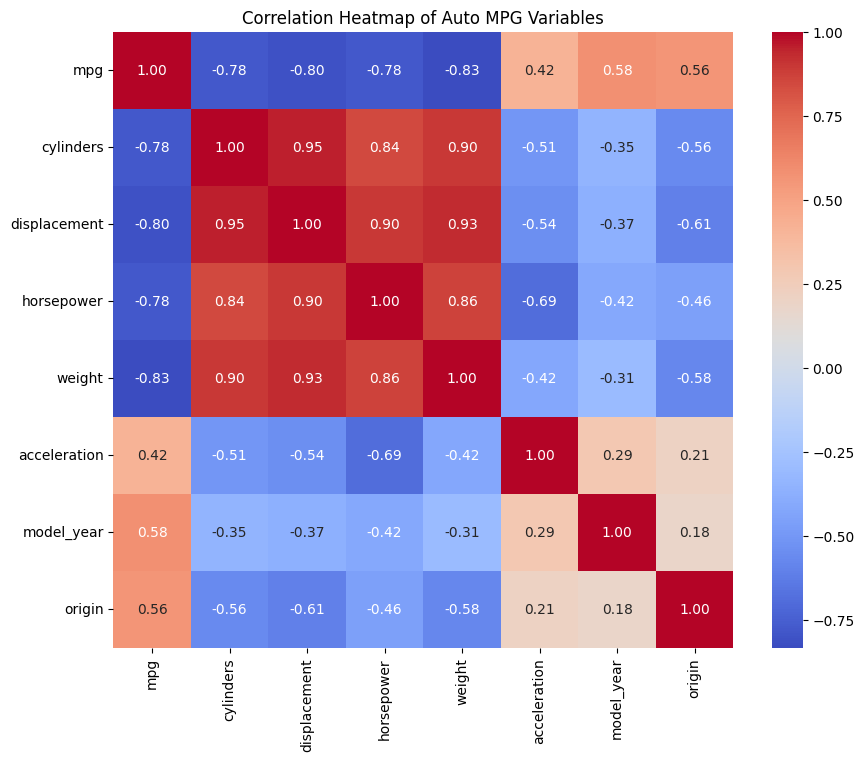

In [4]:
num_cols = [
    "mpg", "cylinders", "displacement", "horsepower",
    "weight", "acceleration", "model_year", "origin"
]

# Compute correlation matrix
corr_matrix = df[num_cols].corr()

# Create heatmap
plt.figure(figsize=(10, 8))
sb.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap of Auto MPG Variables")
plt.show()

The initial analysis of the variables of this dataset show that cylinders, displacement, horsepower, and weight are strongly correlated to each other, but conversely not correlated to good mpg. This makes sense, since heavier, more powerful cars that use more fuel with a larger engine would not be as fuel efficient.

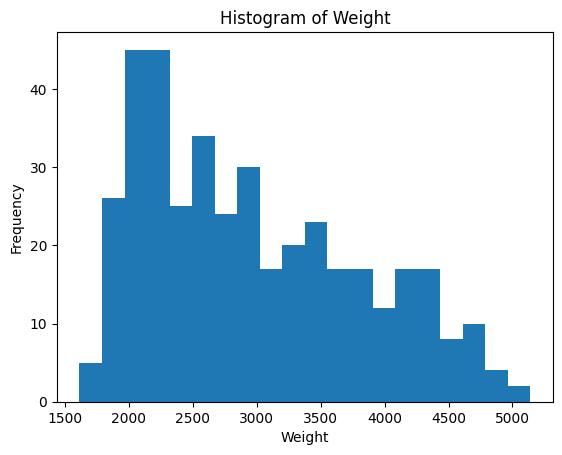

In [5]:
plt.hist(df["weight"].dropna(), bins=20)

plt.title("Histogram of Weight")
plt.xlabel("Weight")
plt.ylabel("Frequency")

plt.show()

As you can see above, the distribution of vehicles MPG is bi-modal, as well as the distribution in the weight of the vehicle is around 2200 pounds.

Here below is the normalization of the numerical attributes.

In [6]:
num_cols = [
    "mpg", "cylinders", "displacement", "horsepower",
    "weight", "acceleration", "model_year", "origin"
]

num_df = df[num_cols].copy()

# ----- Min-Max Normalization -----
minmax_df = (num_df - num_df.min()) / (num_df.max() - num_df.min())

# ----- Z-score Normalization -----
zscore_df = (num_df - num_df.mean()) / num_df.std()

# ----- Decimal Scaling -----
decimal_df = num_df.copy()
for col in num_cols:
    max_val = num_df[col].abs().max()
    j = len(str(int(max_val)))
    decimal_df[col] = num_df[col] / (10 ** j)

print("Min-Max Normalized:\n", minmax_df.head())
print("\nZ-score Normalized:\n", zscore_df.head())
print("\nDecimal Scaled:\n", decimal_df.head())

Min-Max Normalized:
         mpg  cylinders  displacement  horsepower    weight  acceleration  \
0  0.239362        1.0      0.617571    0.456522  0.536150      0.238095   
1  0.159574        1.0      0.728682    0.646739  0.589736      0.208333   
2  0.239362        1.0      0.645995    0.565217  0.516870      0.178571   
3  0.186170        1.0      0.609819    0.565217  0.516019      0.238095   
4  0.212766        1.0      0.604651    0.510870  0.520556      0.148810   

   model_year  origin  
0         0.0     0.0  
1         0.0     0.0  
2         0.0     0.0  
3         0.0     0.0  
4         0.0     0.0  

Z-score Normalized:
         mpg  cylinders  displacement  horsepower    weight  acceleration  \
0 -0.705551   1.496308      1.089233    0.663285  0.630077     -1.293870   
1 -1.089379   1.496308      1.501624    1.572585  0.853259     -1.475181   
2 -0.705551   1.496308      1.194728    1.182885  0.549778     -1.656492   
3 -0.961437   1.496308      1.060461    1.182885  0.

Now this is the binning of a continuous variable, in this case, it is the mpg value.

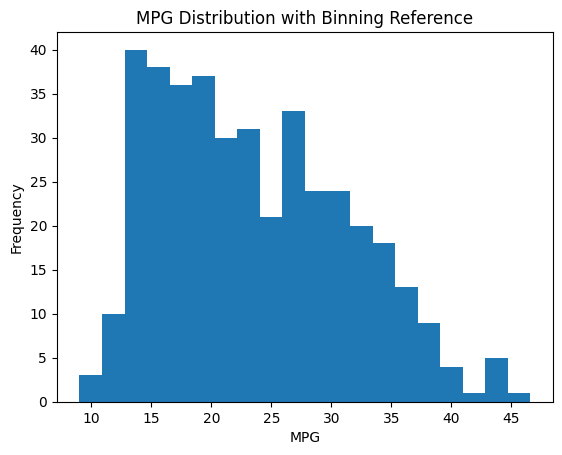

In [7]:
plt.hist(df["mpg"], bins=20)
plt.title("MPG Distribution with Binning Reference")
plt.xlabel("MPG")
plt.ylabel("Frequency")
plt.show()

Lastly, we will transform a non-normal variable.

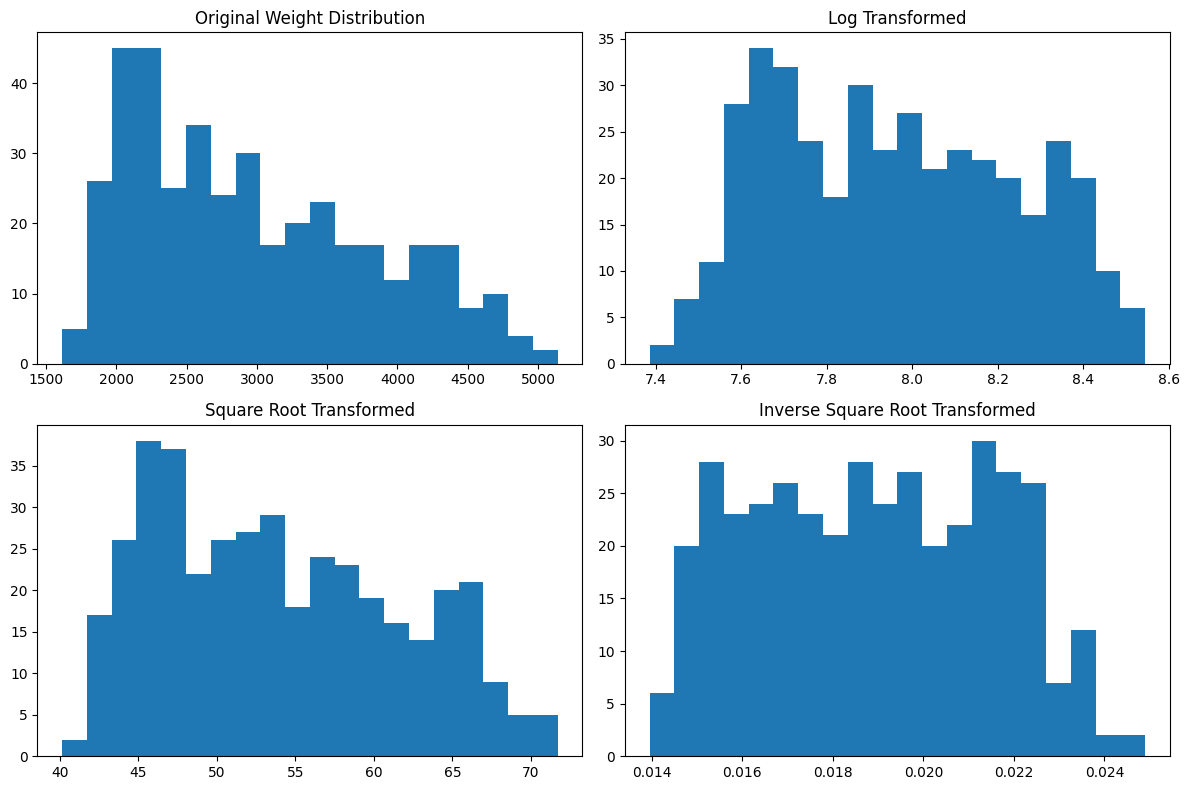

In [8]:
weight = df["weight"].dropna()

# Transformations
log_weight = np.log(weight)
sqrt_weight = np.sqrt(weight)
inv_sqrt_weight = 1 / np.sqrt(weight)

# Plot all distributions
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.hist(weight, bins=20)
plt.title("Original Weight Distribution")

plt.subplot(2, 2, 2)
plt.hist(log_weight, bins=20)
plt.title("Log Transformed")

plt.subplot(2, 2, 3)
plt.hist(sqrt_weight, bins=20)
plt.title("Square Root Transformed")

plt.subplot(2, 2, 4)
plt.hist(inv_sqrt_weight, bins=20)
plt.title("Inverse Square Root Transformed")

plt.tight_layout()
plt.show()

The variable weight showed a right-skewed distribution, indicating it was not normally distributed. Applying transformations helped reduce skewness. The natural log transformation produced the most symmetric, bell-shaped distribution, suggesting it best improved normality. The square root transformation moderately reduced skewness but still retained some asymmetry. The inverse square root transformation overly compressed larger values and did not approximate normality well. Therefore, the log transformation was the most effective method for normalizing the weight distribution.

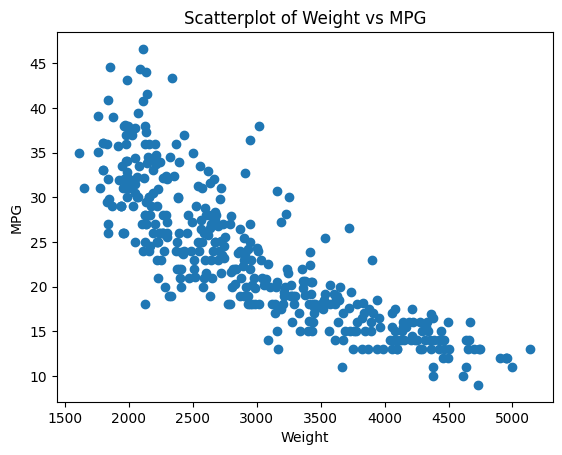

In [9]:
plt.scatter(df["weight"], df["mpg"])

plt.title("Scatterplot of Weight vs MPG")
plt.xlabel("Weight")
plt.ylabel("MPG")

plt.show()

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Define independent variables (features) and dependent variable (target)
X_columns = [
    "weight",
    "horsepower",
    "displacement",
    "cylinders",
    "acceleration",
    "model_year"
]
y_column = "mpg"

# Create a new DataFrame with only the relevant columns and drop rows with any NaN values
# This is important as horsepower has NaNs
df_model = df[X_columns + [y_column]].dropna()

X = df_model[X_columns]
y = df_model[y_column]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
r_squared = r2_score(y_test, y_pred)

print("\n--- Linear Regression Model Results ---")
print("Independent Variables:", X_columns)
print("Dependent Variable:", y_column)
print("\nModel Coefficients:")
for feature, coef in zip(X_columns, model.coef_):
    print(f"  {feature}: {coef:.4f}")
print(f"  Intercept: {model.intercept_:.4f}")
print(f"\nR-squared (on test set): {r_squared:.4f}")


--- Linear Regression Model Results ---
Independent Variables: ['weight', 'horsepower', 'displacement', 'cylinders', 'acceleration', 'model_year']
Dependent Variable: mpg

Model Coefficients:
  weight: -0.0066
  horsepower: -0.0023
  displacement: 0.0010
  cylinders: -0.1162
  acceleration: 0.0617
  model_year: 0.7606
  Intercept: -15.0578

R-squared (on test set): 0.7942
